# RealLift Demonstration: DoE - Design of Experiments

## 1. Installation

In [ ]:
# From GitHub
# %pip install git+https://github.com/RobertoJuniorWXYZ/RealLift.git
# or
# From PyPI
%pip install reallift

## 2. Generate Simulated Data

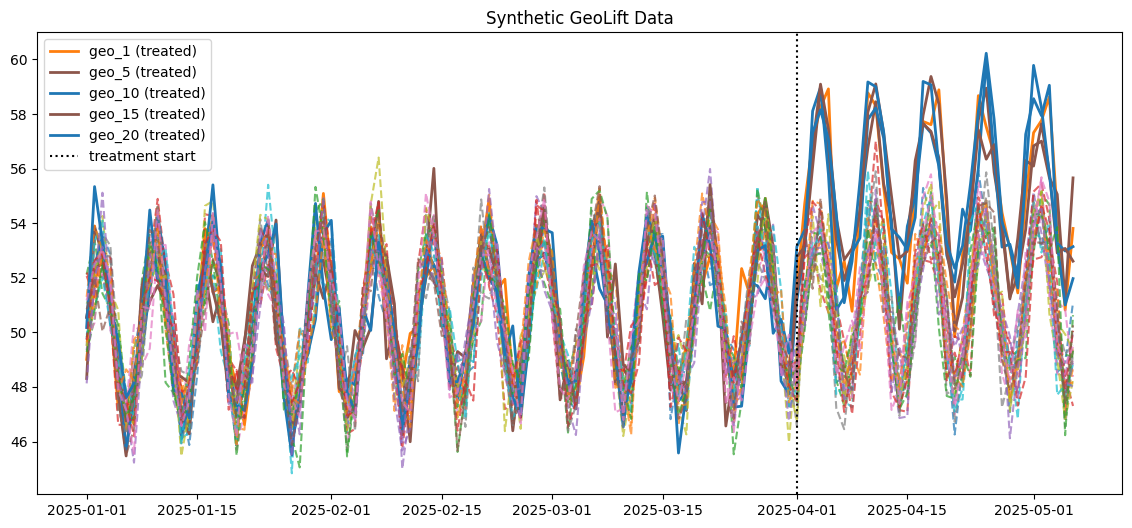

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from reallift import generate_geolift_data

# Parameters for simulation
file_pre_test = 'demo_geodata_pre_test.csv'
file_post_test = 'demo_geodata_post_test.csv'
start_date = "2025-01-01"
treatment_start = "2025-04-01"
end_date = pd.to_datetime(treatment_start) + pd.Timedelta(days=35)

df, df_pre, treated = generate_geolift_data(
    start_date = start_date,
    treatment_start = treatment_start,
    end_date = end_date,
    n_geos=27,
    treatment_geos=["geo_1","geo_5","geo_10","geo_15","geo_20"],
    lift=0.08,  # lift post test
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=1,
    save_csv=True,
    file_name=file_post_test,
    pre_file_name=file_pre_test,
)

## 3. Identifying Clusters
### Identifying Clusters (`find_best_geo_clusters`)
This function searches for the optimal combination of treatment and control geographies to minimize pre-treatment error and maximize the correlation between groups.
**Key Options:**
- `n_treatment`: Defines how many treatment groups to test (e.g., 2 for an A/B test across two cities).
- `fixed_treatment`: Allows you to force specific cities into the treatment group.
> [!TIP]
> **Recommendation:** Use at least 2 months of historical data to ensure the algorithm finds controls that accurately capture the treatment's seasonality.
**What it does:** It uses a regularized linear model to identify which controls best explain the treatment group's trend, returning a list of **Clusters** ready for individual analysis.


In [2]:
from reallift.geo.split import find_best_geo_clusters

clusters = find_best_geo_clusters(
    filepath=file_pre_test,
    date_col="date",
    n_treatment=5,
    fixed_treatment=["geo_1","geo_5","geo_10","geo_15","geo_20"]
)


=== BEST CLUSTERS FOUND ===
Cluster 0: Treatment ['geo_10'], Correlation 0.9085
Cluster 1: Treatment ['geo_1'], Correlation 0.8345
Cluster 2: Treatment ['geo_15'], Correlation 0.7913
Cluster 3: Treatment ['geo_20'], Correlation 0.7744
Cluster 4: Treatment ['geo_5'], Correlation 0.7640


## 4. Validation

Cross-Validation (`validate_geo_groups`)
Performs a historical simulation (backtesting) to verify the model's ability to predict the treatment group's behavior *before* any actual intervention occurs.
**Key Options:**
- `n_folds`: Number of windows for **Time Series Cross-Validation**. We recommend using `n_folds=5` for better robustness.
- `train_test_split`: Defines the train/test ratio if you choose to use only 1 fold (static validation).
> [!IMPORTANT]
> **Success Metrics:** Aim for an **R2 > 0.8** in Cross-Validation. A large gap between Train R2 and OOF R2 (above 0.20) may indicate potential overfitting.
**What it does:** It splits historical data into training and testing windows. If the model can accurately predict the past, we gain high confidence that it will successfully capture the incremental effect during the real test.


=== GEO CLUSTER VALIDATION (Cluster 0) ===
Treatment: ['geo_10']
Control: ['geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9', 'geo_11', 'geo_14', 'geo_16', 'geo_17', 'geo_19', 'geo_23', 'geo_24', 'geo_25', 'geo_26']

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8999 | Average OOF R2: 0.8474
Average Train MAPE: 0.0125 | Average OOF MAPE: 0.0138
Average Train WAPE: 0.0125 | Average OOF WAPE: 0.0138


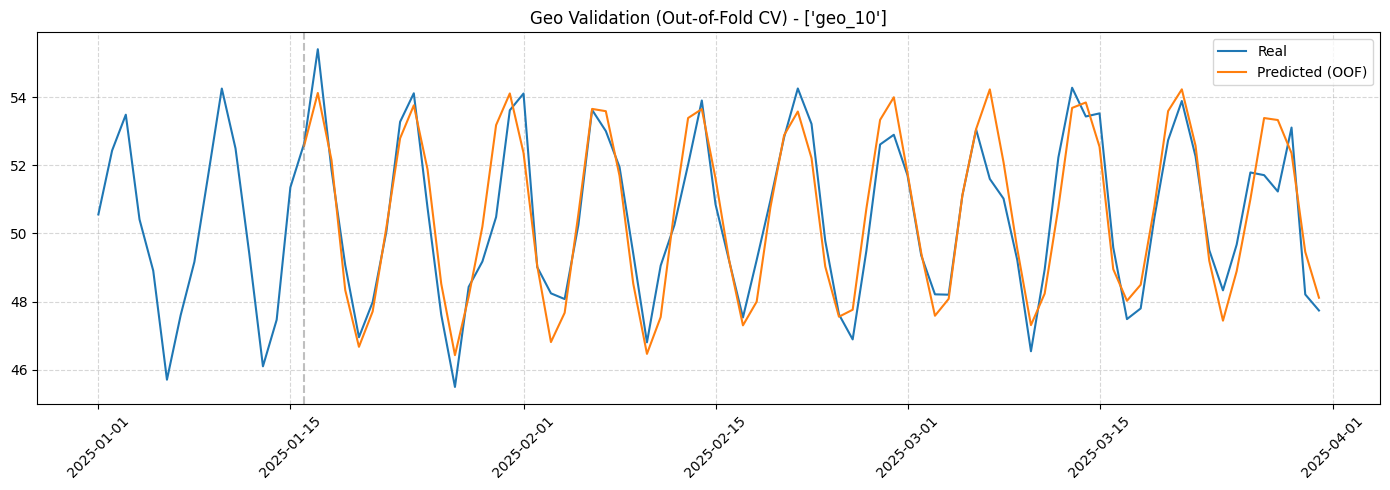


=== GEO CLUSTER VALIDATION (Cluster 1) ===
Treatment: ['geo_1']
Control: ['geo_0', 'geo_2', 'geo_4', 'geo_9', 'geo_11', 'geo_12', 'geo_13', 'geo_14', 'geo_16', 'geo_17', 'geo_19', 'geo_21', 'geo_22', 'geo_24', 'geo_25']

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8641 | Average OOF R2: 0.7868
Average Train MAPE: 0.0142 | Average OOF MAPE: 0.0158
Average Train WAPE: 0.0141 | Average OOF WAPE: 0.0158


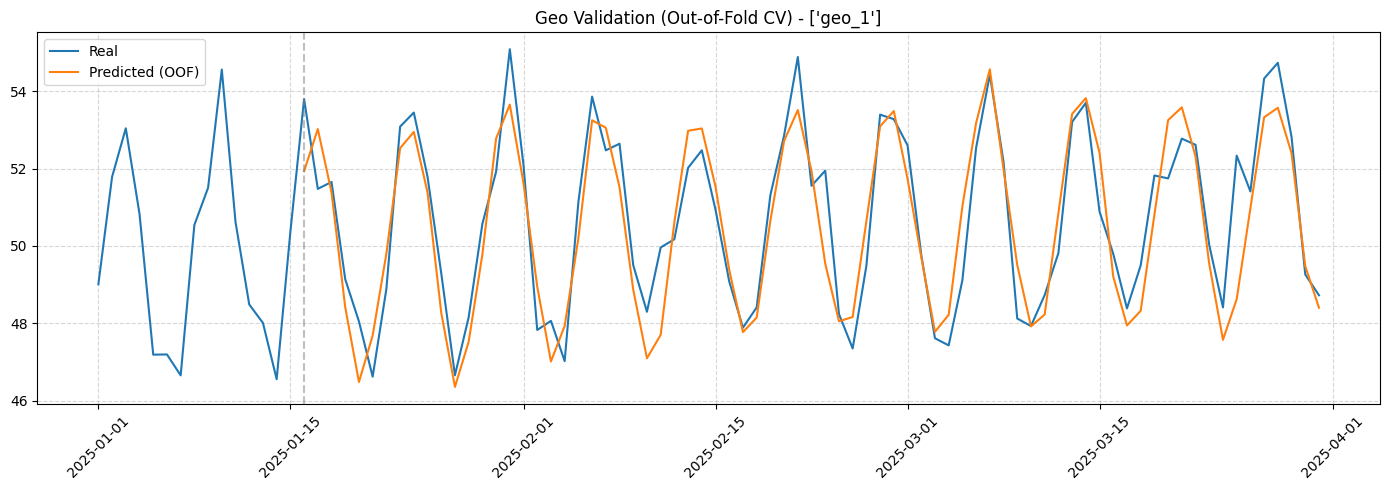


=== GEO CLUSTER VALIDATION (Cluster 2) ===
Treatment: ['geo_15']
Control: ['geo_0', 'geo_3', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_11', 'geo_14', 'geo_16', 'geo_18', 'geo_19', 'geo_25', 'geo_26']

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.7980 | Average OOF R2: 0.7689
Average Train MAPE: 0.0153 | Average OOF MAPE: 0.0172
Average Train WAPE: 0.0153 | Average OOF WAPE: 0.0173


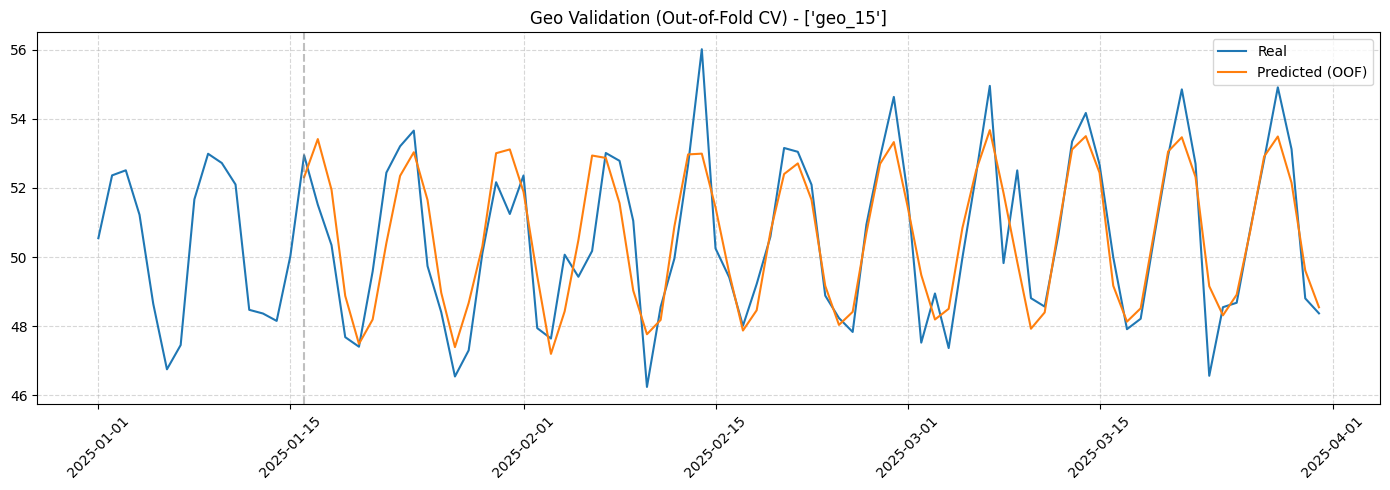


=== GEO CLUSTER VALIDATION (Cluster 3) ===
Treatment: ['geo_20']
Control: ['geo_2', 'geo_3', 'geo_4', 'geo_8', 'geo_9', 'geo_17', 'geo_18', 'geo_22', 'geo_24', 'geo_25', 'geo_26']

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.7941 | Average OOF R2: 0.7146
Average Train MAPE: 0.0178 | Average OOF MAPE: 0.0187
Average Train WAPE: 0.0179 | Average OOF WAPE: 0.0186


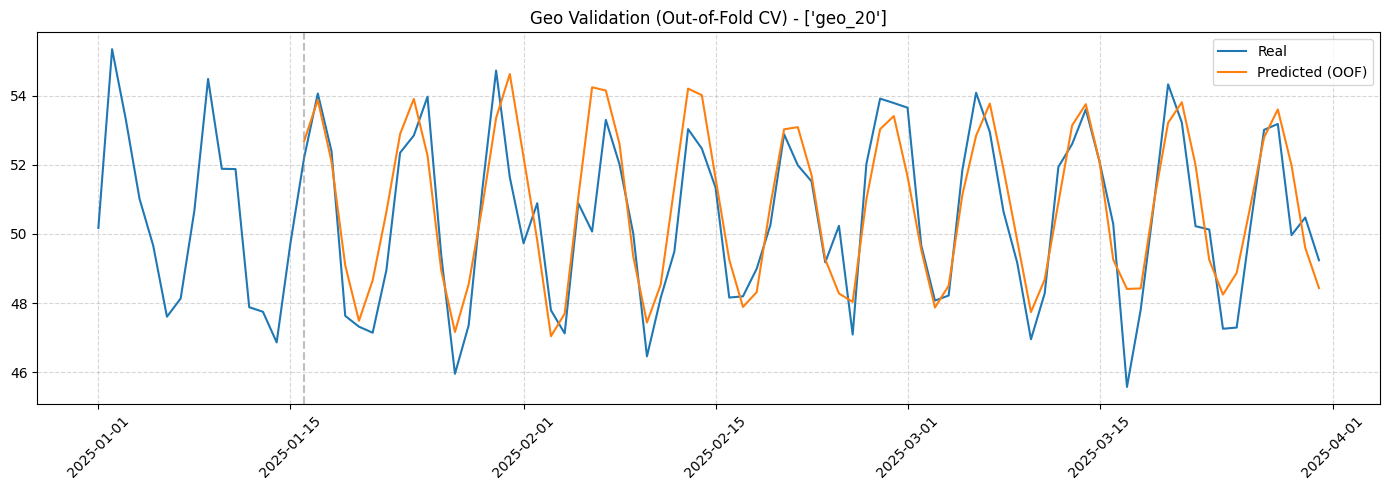


=== GEO CLUSTER VALIDATION (Cluster 4) ===
Treatment: ['geo_5']
Control: ['geo_0', 'geo_4', 'geo_6', 'geo_7', 'geo_9', 'geo_11', 'geo_14', 'geo_17', 'geo_18', 'geo_19', 'geo_21', 'geo_23', 'geo_24']

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.7824 | Average OOF R2: 0.7561
Average Train MAPE: 0.0160 | Average OOF MAPE: 0.0166
Average Train WAPE: 0.0159 | Average OOF WAPE: 0.0166


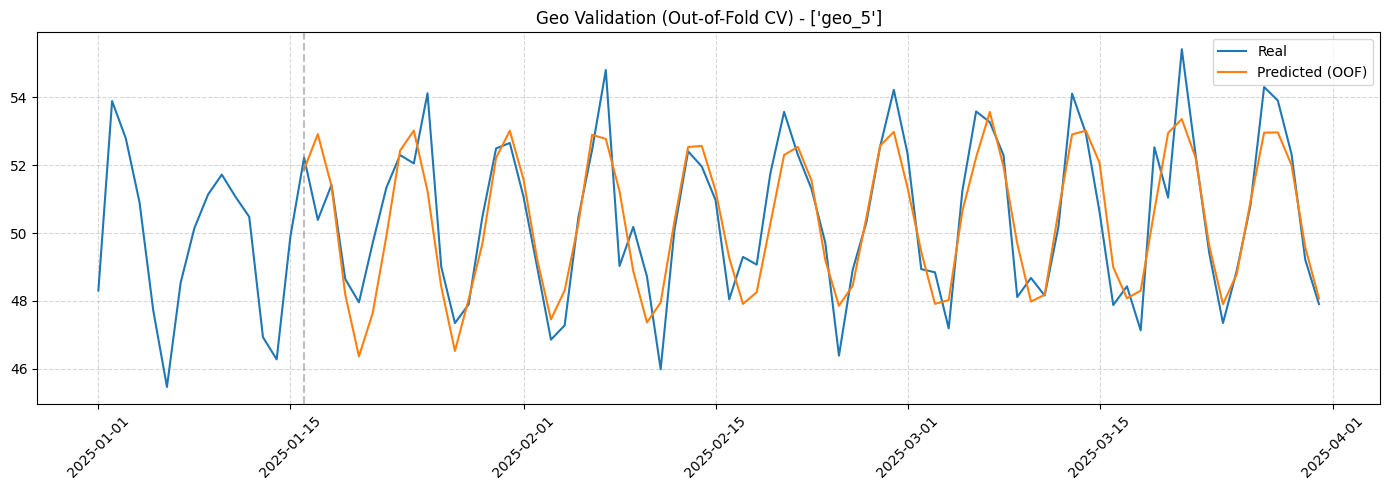

In [4]:
from reallift.geo.validation import validate_geo_groups

validation = validate_geo_groups(
    filepath=file_pre_test,
    date_col="date",
    splits=clusters,
    n_folds=5,
    plot=True,
    export_csv=False,
)


## Estimate Duration
### Duration Estimation (`estimate_duration`)
Calculates the minimum time required for the experiment to have enough statistical power to detect the desired impact (Lift).
**Key Options:**
- `mde`: Minimum Detectable Effect (e.g., 0.015 for 1.5%). This is the smallest impact you wish to detect with confidence.
- `power_target`: Statistical power target (default 0.8 or 80%).
- `max_days`: Limit of days for the duration simulation.
> [!NOTE]
> **Recommendation:** If the estimated duration is too long (> 6 weeks), try slightly increasing the MDE or looking for a cluster with higher correlation in step 6.1.
**What it does:** It estimates the historical residual error variance and applies power analysis to determine the sample size (days) needed to distinguish signal from noise.

In [5]:
from reallift.geo.duration import estimate_duration

for i, cluster in enumerate(clusters):
    summary = estimate_duration(
        filepath=file_pre_test,
        date_col="date",
        treatment_geo=cluster["treatment"][0],
        control_geos=cluster["control"],
        mde=0.015,
        max_days=60,
        cluster_idx=i
    )


=== GEO DURATION ESTIMATION (Cluster 0) ===
Treatment: geo_10
Control: ['geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9', 'geo_11', 'geo_14', 'geo_16', 'geo_17', 'geo_19', 'geo_23', 'geo_24', 'geo_25', 'geo_26']

=== STATISTICS ===
Mean: 50.48
Std Residual: 0.0186
R-Squared: 0.8261
Correlation: 0.934

=== MDE ===
MDE: 1.50%
Effect absolute: 0.76
Effect percent real: 1.50%

=== RESULT ===
✔ Min duration: 13 days
✔ Power: 82.43%

=== GEO DURATION ESTIMATION (Cluster 1) ===
Treatment: geo_1
Control: ['geo_0', 'geo_2', 'geo_4', 'geo_9', 'geo_11', 'geo_12', 'geo_13', 'geo_14', 'geo_16', 'geo_17', 'geo_19', 'geo_21', 'geo_22', 'geo_24', 'geo_25']

=== STATISTICS ===
Mean: 50.57
Std Residual: 0.0245
R-Squared: 0.6973
Correlation: 0.911

=== MDE ===
MDE: 1.50%
Effect absolute: 0.76
Effect percent real: 1.50%

=== RESULT ===
✔ Min duration: 22 days
✔ Power: 81.39%

=== GEO DURATION ESTIMATION (Cluster 2) ===
Treatment: geo_15
Control: ['geo_0', 'geo_3', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_11',